<a href="https://colab.research.google.com/github/hanifanwibawa/datanaly/blob/Chol/CleanDrop_Chol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/wahana.csv')

In [ ]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,female,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,man,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,male,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
df.shape

(1380, 16)

In [ ]:
print (f'total baris : {df.shape[0]}')
print (f'total kolom : {df.shape[1]}')

total baris : 1380
total kolom : 16


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        1380 non-null   int64  
 1   age       1380 non-null   int64  
 2   sex       1380 non-null   object 
 3   dataset   1380 non-null   object 
 4   cp        1380 non-null   object 
 5   trestbps  1281 non-null   float64
 6   chol      1343 non-null   float64
 7   fbs       1268 non-null   object 
 8   restecg   1378 non-null   object 
 9   thalch    1291 non-null   float64
 10  exang     1291 non-null   object 
 11  oldpeak   1264 non-null   float64
 12  slope     877 non-null    object 
 13  ca        457 non-null    float64
 14  thal      672 non-null    object 
 15  num       1380 non-null   int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 172.6+ KB


In [ ]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [ ]:
df.describe() # yang ditampilkan hanya niai numerik

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,1380.000000,1380.000000,1281.000000,1343.000000,1291.000000,1264.000000,457.000000,1380.000000
mean,458.531884,53.754348,133.023419,202.153388,137.446940,0.851187,0.641138,1.062319
std,266.962952,9.882989,18.457580,112.141412,26.352752,1.060714,0.897299,1.169668
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,236.000000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,449.500000,55.000000,130.000000,226.000000,140.000000,0.400000,0.000000,1.000000
75%,701.250000,61.000000,145.000000,272.000000,156.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

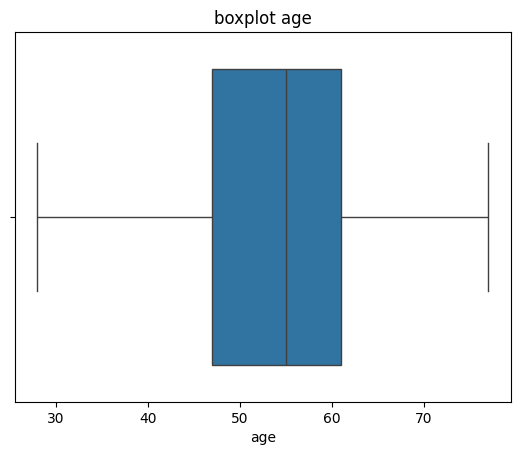

In [ ]:
sns.boxplot(x=df['age'])
plt.title('boxplot age')
plt.show()

# Min, Q1, Q2, Q3, Max sesuai dgn tabel

In [ ]:
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [ ]:
print(f'data numerik : {num_cols}')
print(f'data kategorik : {cat_cols}')

data numerik : Index(['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num'], dtype='object')
data kategorik : Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')


In [ ]:
data_kosong = df.isnull().sum()

print(f'data_kosong \n{data_kosong}')

data_kosong 
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     99
chol         37
fbs         112
restecg       2
thalch       89
exang        89
oldpeak     116
slope       503
ca          923
thal        708
num           0
dtype: int64


In [ ]:
data_kosong = data_kosong[data_kosong > 0]

print(f'data yang kosong \n{data_kosong}')

data yang kosong 
trestbps     99
chol         37
fbs         112
restecg       2
thalch       89
exang        89
oldpeak     116
slope       503
ca          923
thal        708
dtype: int64


In [ ]:
data_duplkat = df.duplicated().sum()

print(f'data duplikat : {data_duplkat}')

data duplikat : 460


In [ ]:
df[df.duplicated()]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
920,245,60,male,Cleveland,non-anginal,120.0,178.0,True,normal,96.0,False,0.0,upsloping,0.0,normal,0
921,31,69,male,Cleveland,typical angina,140.0,239.0,False,normal,151.0,False,1.8,upsloping,2.0,normal,0
922,295,63,female,Cleveland,asymptomatic,124.0,197.0,False,normal,136.0,True,0.0,flat,0.0,normal,1
923,315,34,male,Hungary,atypical angina,98.0,220.0,False,normal,150.0,False,0.0,NaN,NaN,NaN,0
924,45,61,female,Cleveland,asymptomatic,130.0,330.0,False,lv hypertrophy,169.0,False,0.0,upsloping,0.0,normal,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1375,797,49,male,VA Long Beach,typical angina,130.0,0.0,False,st-t abnormality,145.0,False,3.0,flat,NaN,NaN,2
1376,320,36,woman,Hungary,atypical angina,120.0,166.0,False,normal,180.0,False,0.0,NaN,NaN,NaN,0
1377,297,59,female,Cleveland,asymptomatic,164.0,176.0,True,lv hypertrophy,90.0,False,1.0,flat,2.0,fixed defect,3
1378,465,55,woman,Hungary,atypical angina,145.0,326.0,False,normal,155.0,False,0.0,NaN,NaN,NaN,0


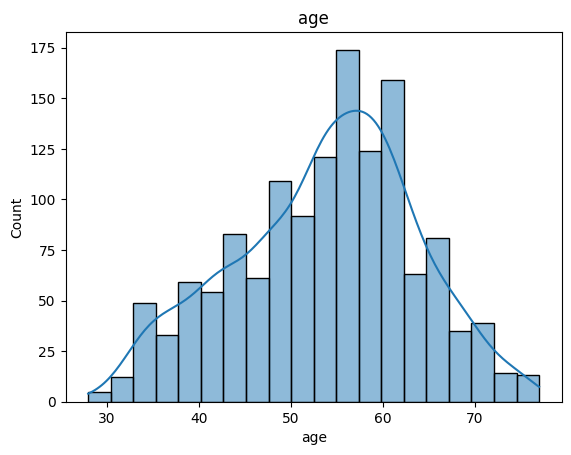

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['age'], kde= True)
plt.title('age')
plt.show()

# didapatkan hasil gaussian (condong ke tengah)

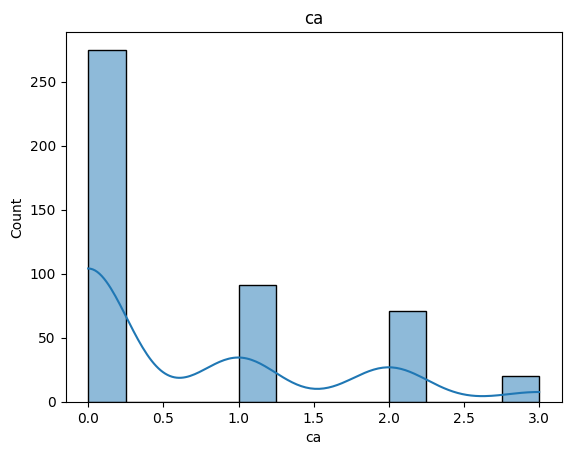

In [ ]:
sns.histplot(df['ca'], kde= True)
plt.title('ca')
plt.show()

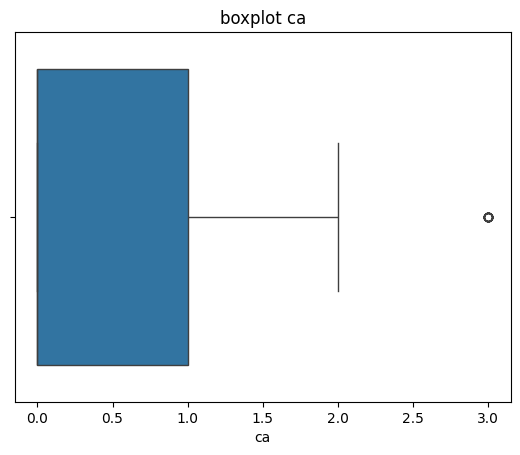

In [ ]:
sns.boxplot(x=df['ca'])
plt.title('boxplot ca')
plt.show()

In [ ]:
# kde = kernel distribusi entity

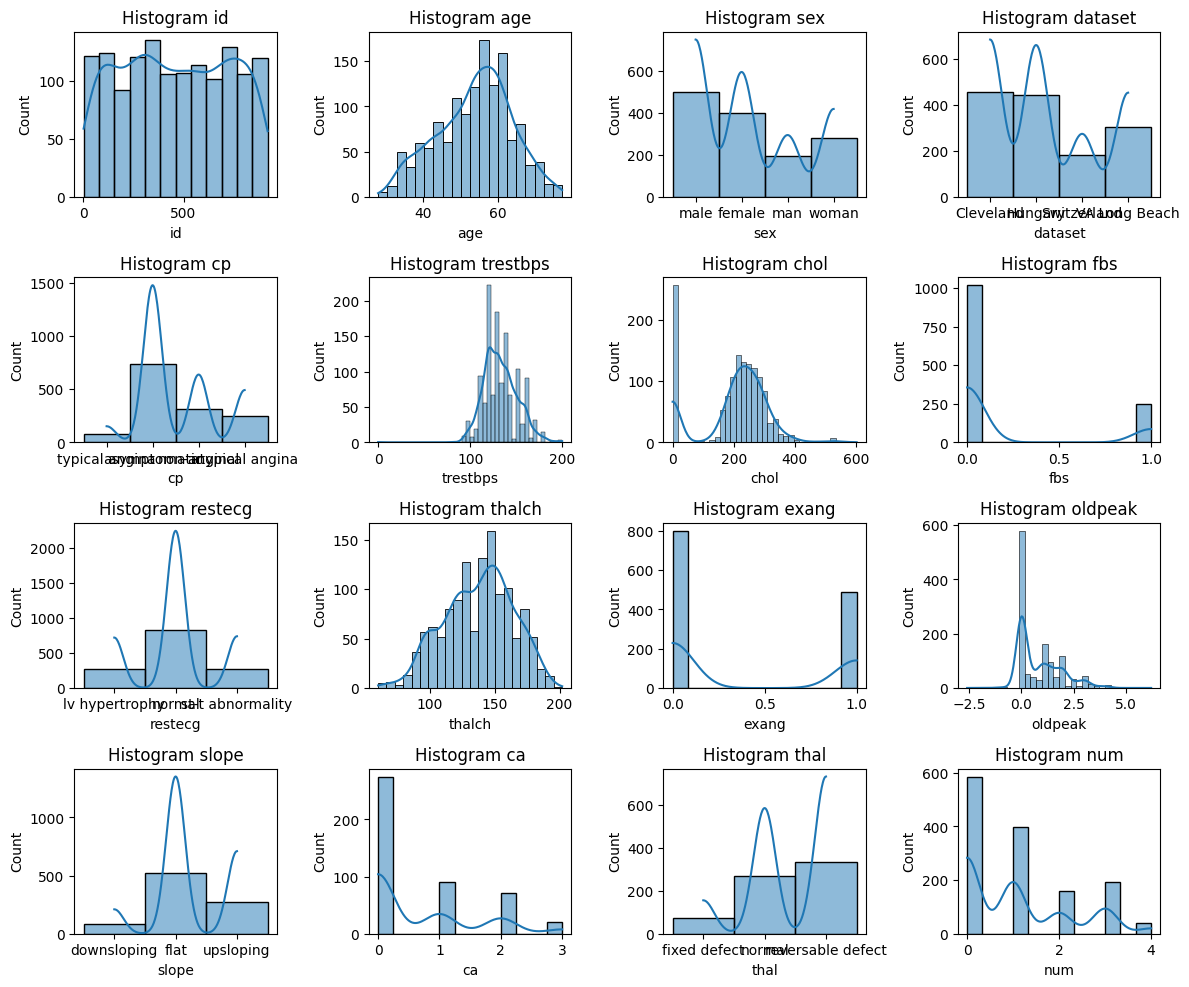

In [ ]:
plt.figure(figsize=(12, 12))

for i, col in enumerate(df.columns,1) :
  plt.subplot(5,4,i)
  sns.histplot(df[col], kde= True)
  plt.title(f'Histogram {col}')
plt.tight_layout()

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

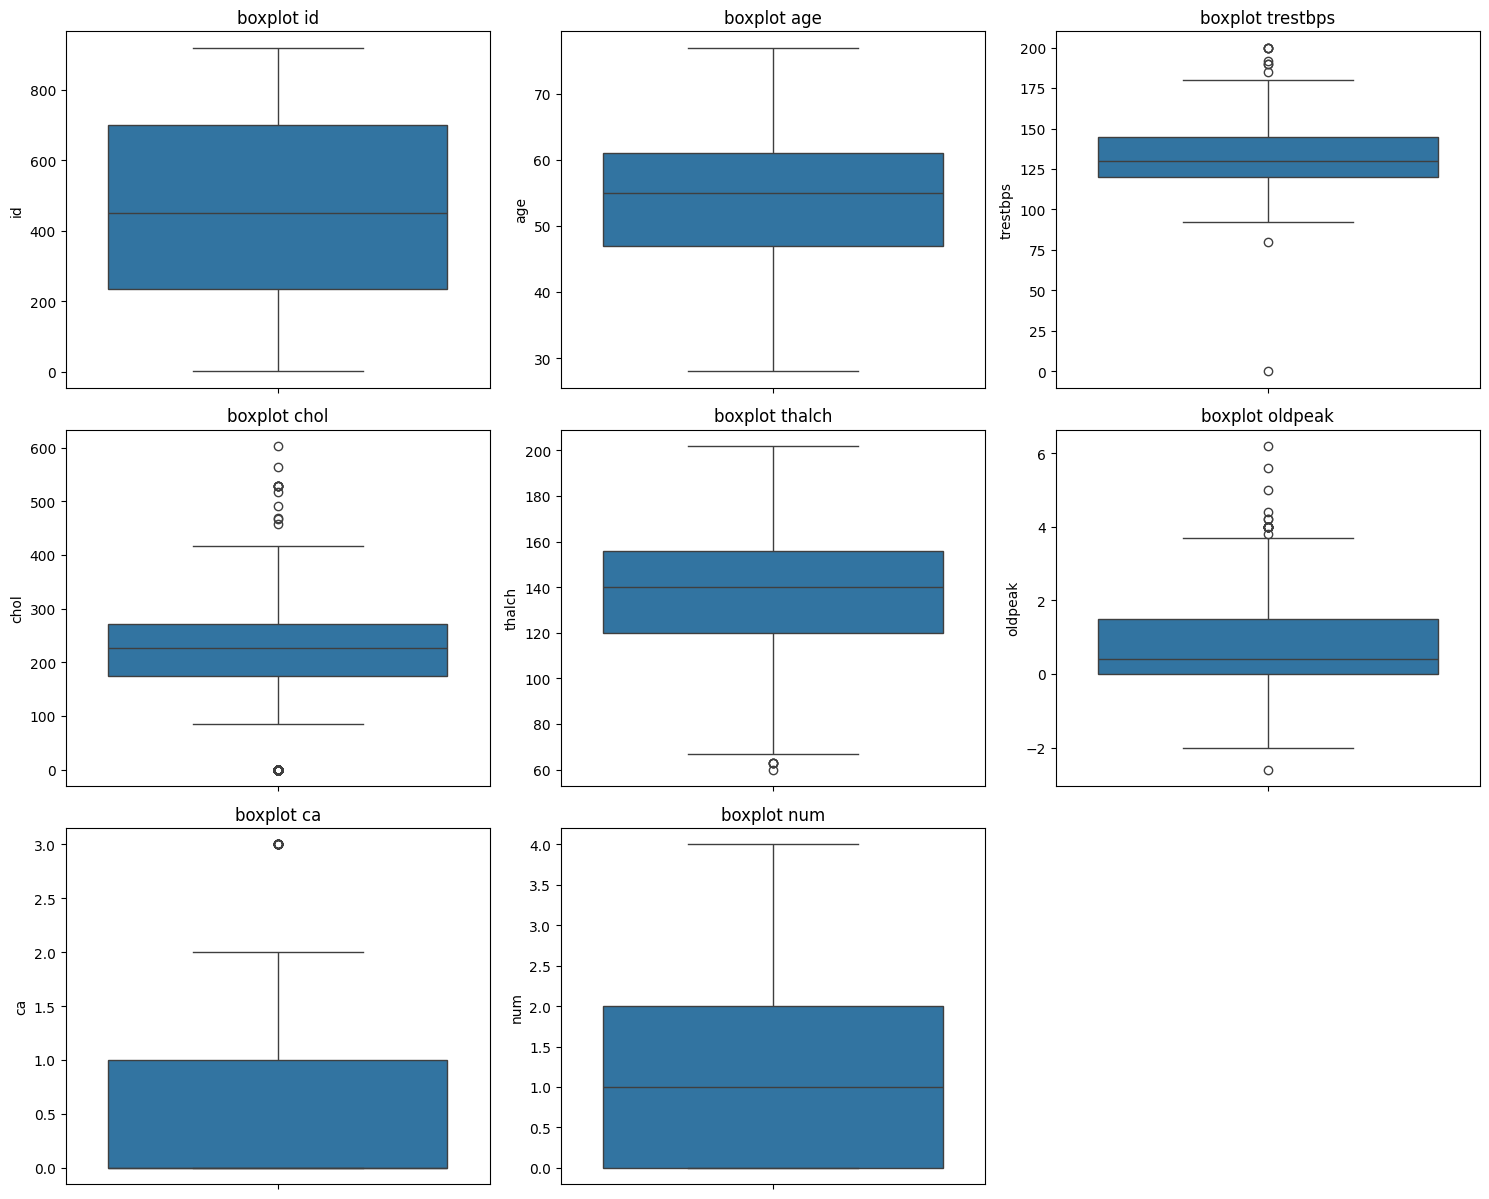

In [ ]:
import numpy as np

n_cols = 3

n_rows = int(np.ceil(len(df.columns) / n_cols))

plt.figure(figsize=(n_cols*5, n_rows*4))
for i, col in enumerate(num_cols, 1) :
  plt.subplot(n_rows, n_cols, i)
  sns.boxplot(df[col])
  plt.title(f'boxplot {col}')
plt.tight_layout()
plt.show

In [ ]:
df['sex'].unique()

array(['male', 'female', 'man', 'woman'], dtype=object)

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols :
  print(f'Kolom {col}')
  print(df[col].unique())

Kolom sex
['male' 'female' 'man' 'woman']
Kolom dataset
['Cleveland' 'Hungary' 'Switzerland' 'VA Long Beach']
Kolom cp
['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']
Kolom fbs
[True False nan]
Kolom restecg
['lv hypertrophy' 'normal' 'st-t abnormality' nan]
Kolom exang
[False True nan]
Kolom slope
['downsloping' 'flat' 'upsloping' nan]
Kolom thal
['fixed defect' 'normal' 'reversable defect' nan]


**PRE PROCESSING DATA**

In [ ]:
df_new = df.copy()

In [ ]:
df_new['sex'] = df_new['sex'].replace(
    {
        'woman' : 'female',
        'man' : 'male'
    }
)

In [ ]:
print (f'before : {df['sex'].unique()}')
print (f'after : {df_new['sex'].unique()}')

before : ['male' 'female' 'man' 'woman']
after : ['male' 'female']


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = df_new.select_dtypes(include=['object']).columns.tolist()

mappings = {}
for col in cat_cols :
  df_new[col] = le.fit_transform(df_new[col].astype(str))
  mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))


In [ ]:
mappings

{'sex': {'female': np.int64(0), 'male': np.int64(1)},
 'dataset': {'Cleveland': np.int64(0),
  'Hungary': np.int64(1),
  'Switzerland': np.int64(2),
  'VA Long Beach': np.int64(3)},
 'cp': {'asymptomatic': np.int64(0),
  'atypical angina': np.int64(1),
  'non-anginal': np.int64(2),
  'typical angina': np.int64(3)},
 'fbs': {'False': np.int64(0), 'True': np.int64(1), 'nan': np.int64(2)},
 'restecg': {'lv hypertrophy': np.int64(0),
  'nan': np.int64(1),
  'normal': np.int64(2),
  'st-t abnormality': np.int64(3)},
 'exang': {'False': np.int64(0), 'True': np.int64(1), 'nan': np.int64(2)},
 'slope': {'downsloping': np.int64(0),
  'flat': np.int64(1),
  'nan': np.int64(2),
  'upsloping': np.int64(3)},
 'thal': {'fixed defect': np.int64(0),
  'nan': np.int64(1),
  'normal': np.int64(2),
  'reversable defect': np.int64(3)}}

In [ ]:
df_new.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,2,67,0,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,2,2
2,3,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,3,1
3,4,37,1,0,2,130.0,250.0,0,2,187.0,0,3.5,0,0.0,2,0
4,5,41,1,0,1,130.0,204.0,0,0,172.0,0,1.4,3,0.0,2,0


In [ ]:
df_new.duplicated().sum()

np.int64(460)

In [ ]:
print (f'total data asli : {df_new.shape[0]}')
print (f'total data duplikat : {df_new.duplicated().sum()}')

df_new.drop_duplicates(inplace=True)
print(f'total data setelah dibersihkan : {df_new.shape[0]}')

total data asli : 1380
total data duplikat : 460
total data setelah dibersihkan : 920


In [ ]:
df_new.isnull().sum().sum()

np.int64(817)

In [ ]:
df_new = df_new.drop(['ca'], axis=1)

df_new.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,1,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0,0
1,2,67,0,0,0,160.0,286.0,0,0,108.0,1,1.5,1,2,2
2,3,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,3,1
3,4,37,1,0,2,130.0,250.0,0,2,187.0,0,3.5,0,2,0
4,5,41,1,0,1,130.0,204.0,0,0,172.0,0,1.4,3,2,0


In [ ]:
df_null = df_new.isnull().sum()
df_null = df_null[df_null > 0]

df_null

,0
trestbps,59
chol,30
thalch,55
oldpeak,62


In [ ]:
df_new.isnull().sum().sum()

np.int64(206)

In [ ]:
print (f'total data asli : {df_new.shape[0]}')

df_new.dropna(inplace=True)

print (f'total data yang telah dibersihkan : {df_new.shape[0]}')

total data asli : 920
total data yang telah dibersihkan : 827


In [ ]:
print (f'total data kosong sekarang : {df_new.isnull().sum().sum()}')
print (f'total data duplikasi sekarang : {df_new.duplicated().sum()}')

total data kosong sekarang : 0
total data duplikasi sekarang : 0


<function matplotlib.pyplot.show(close=None, block=None)>

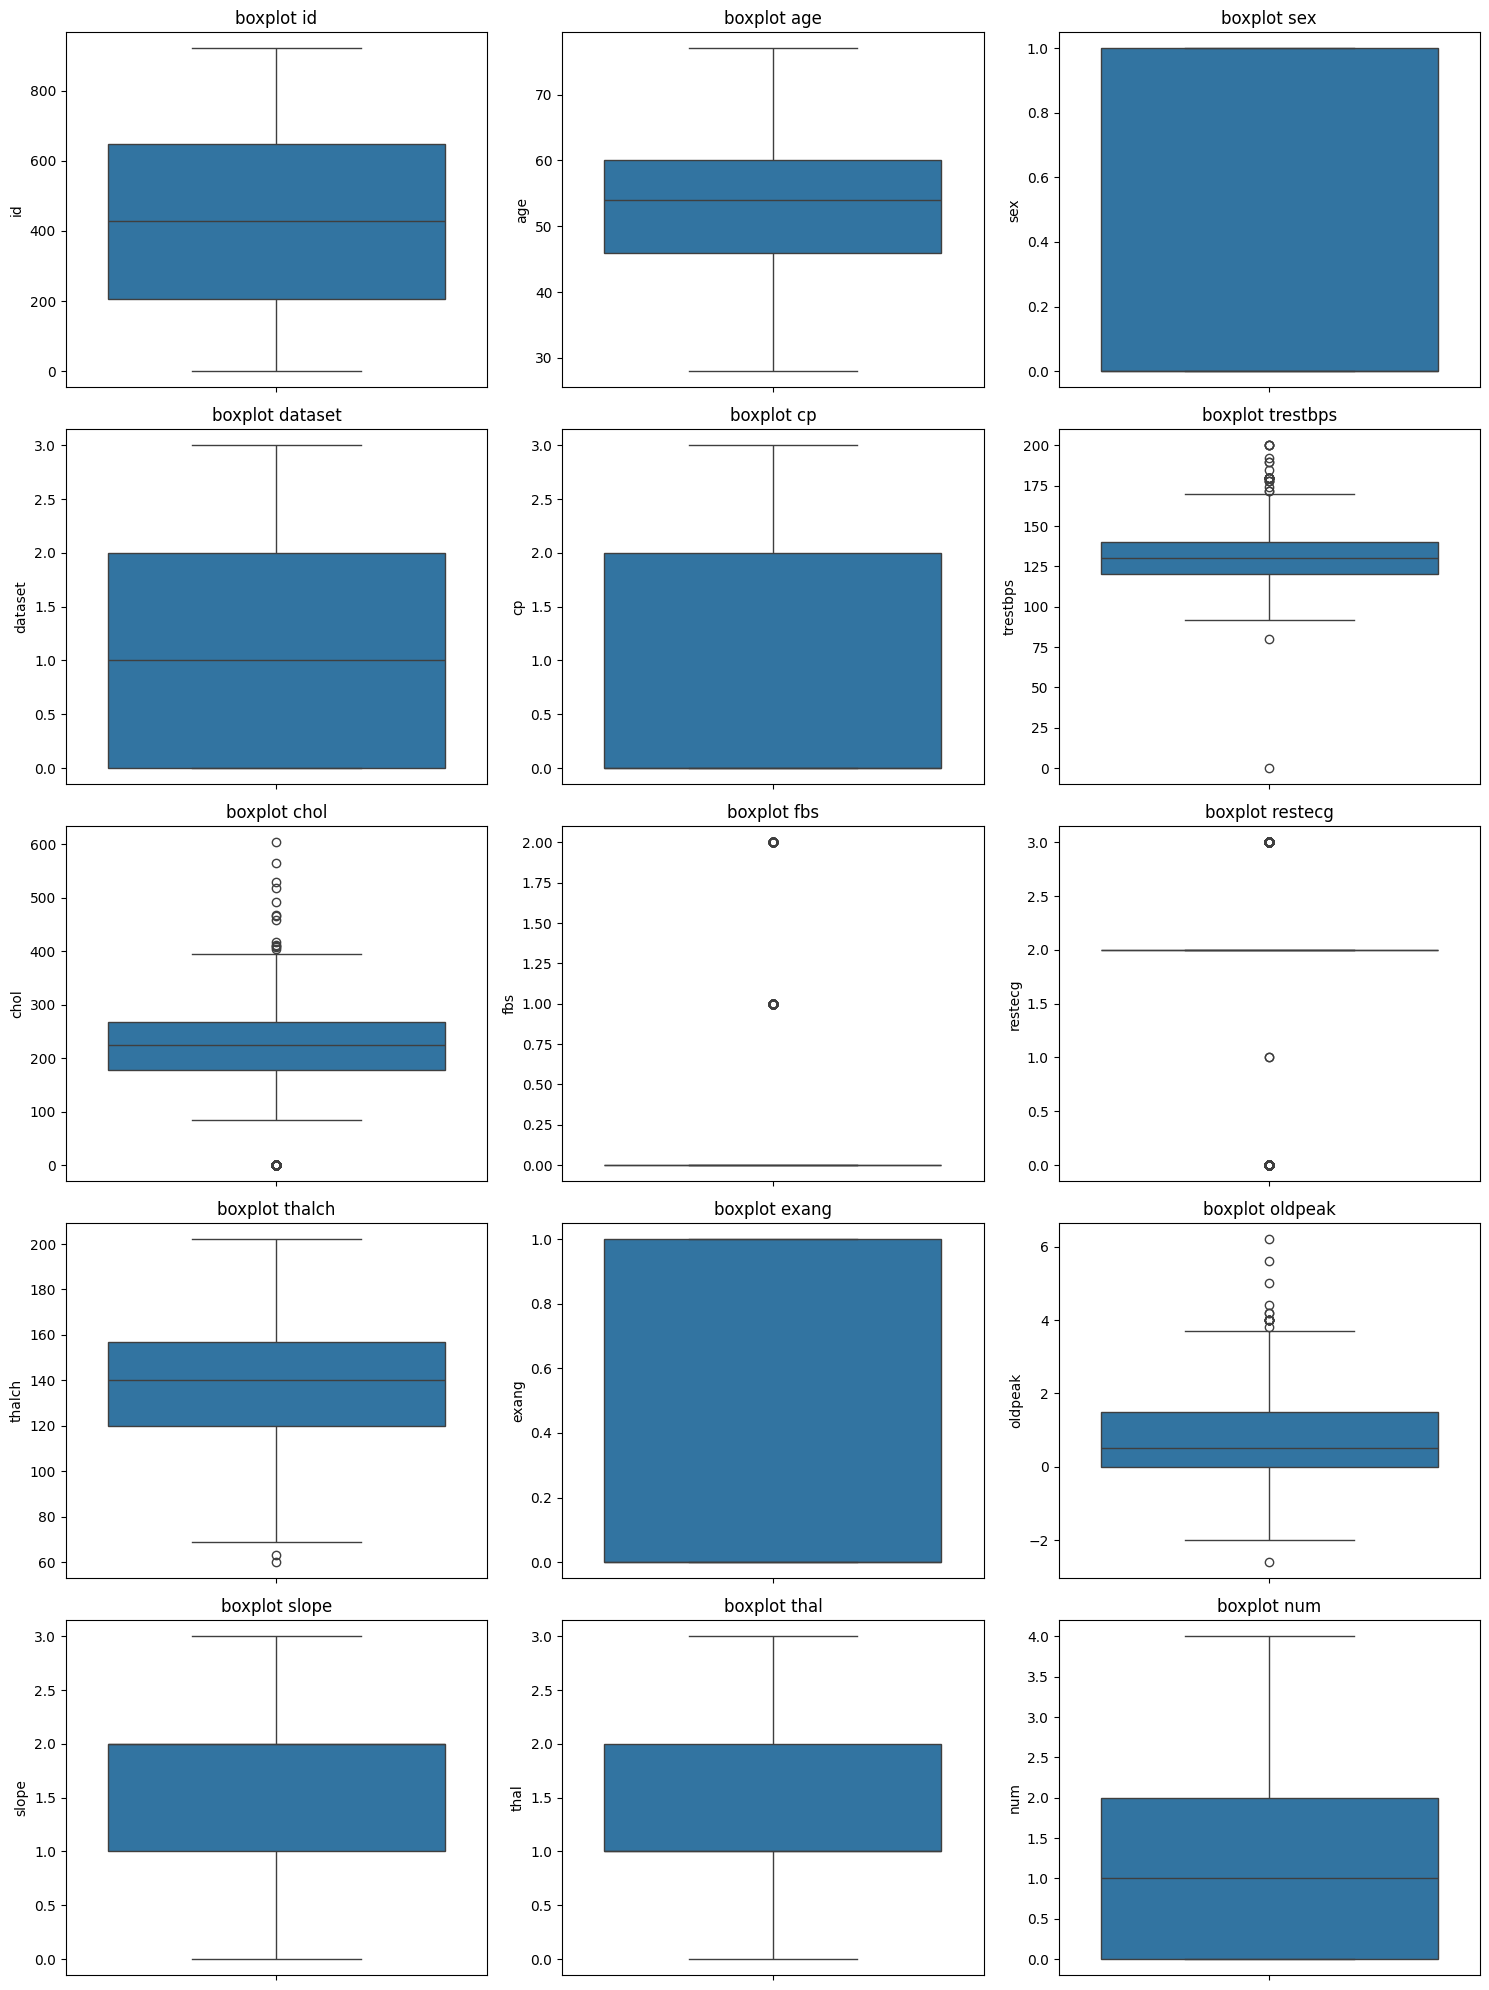

In [ ]:
num_cols = df_new.select_dtypes(include=['number']).columns

n_cols = 3

n_rows = int(np.ceil(len(num_cols) / n_cols))

plt.figure(figsize=(n_cols*5, n_rows*4))
for i, col in enumerate(num_cols, 1) :
  plt.subplot(n_rows, n_cols, i)
  sns.boxplot(df_new[col])
  plt.title(f'boxplot {col}')
plt.tight_layout()
plt.show

In [ ]:
outlier_summary = {}

for col in num_cols :
  q1 = np.nanpercentile(df_new[col], 25)
  q3 = np.nanpercentile(df_new[col], 75)
  iqr = q3 - q1

  lower = q1 - 1.5 * iqr
  upper = q3 + 1.5 * iqr

  outlier = df_new[(df_new[col] < lower) | (df_new[col] > upper)]
  outlier_summary[col] = len(outlier)

In [ ]:
outlier_summary

{'id': 0,
 'age': 0,
 'sex': 0,
 'dataset': 0,
 'cp': 0,
 'trestbps': 27,
 'chol': 168,
 'fbs': 197,
 'restecg': 322,
 'thalch': 2,
 'exang': 0,
 'oldpeak': 16,
 'slope': 0,
 'thal': 0,
 'num': 0}

In [ ]:
df_new.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [ ]:
X = df_new.drop(['num','id'], axis=1)
y = df_new['num']

# X = kolom yg mempengaruhi target, y = target

In [ ]:
print (f'shape X : {X.shape}')
print (f'shape y : {y.shape}')

shape X : (827, 13)
shape y : (827,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(f'ukuran data X_train : {X_train.shape}')
print(f'ukuran data X_test : {X_test.shape}')
print(f'ukuran data y_train : {y_train.shape}')
print(f'ukuran data y_test : {y_test.shape}')

ukuran data X_train : (661, 13)
ukuran data X_test : (166, 13)
ukuran data y_train : (661,)
ukuran data y_test : (166,)


In [ ]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # hanya fit di data training saja
X_test = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train) # hanya menambah sample di data training

Text(0, 0.5, 'Jumlah')

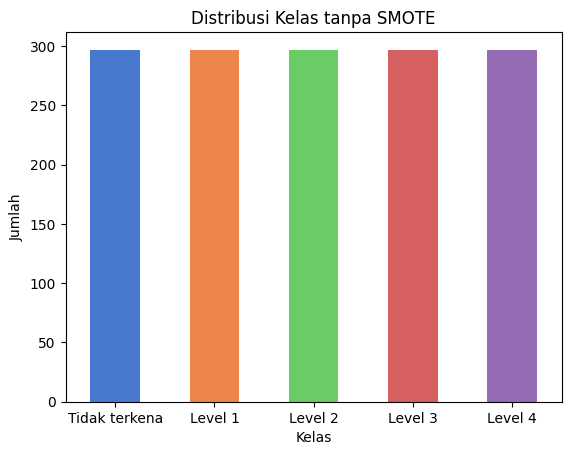

In [ ]:
y_value = {0 : 'Tidak terkena', 1 : 'Level 1', 2 : 'Level 2', 3 : 'Level 3', 4 : 'Level 4'}

palette = sns.color_palette('muted', len(y_value))

ax = y_train.value_counts().plot(kind='bar', color=palette)

plt.xticks(ticks=range(len(y_value)), labels=[y_value[val] for val in range(len(y_value))], rotation=0)

plt.title('Distribusi Kelas tanpa SMOTE')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Akurasi : {accuracy}')

Akurasi : 0.536144578313253


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.80      0.78        74
           1       0.52      0.29      0.37        49
           2       0.24      0.30      0.27        20
           3       0.38      0.44      0.41        18
           4       0.13      0.40      0.20         5

    accuracy                           0.54       166
   macro avg       0.41      0.45      0.40       166
weighted avg       0.56      0.54      0.54       166



<Figure size 800x600 with 0 Axes>

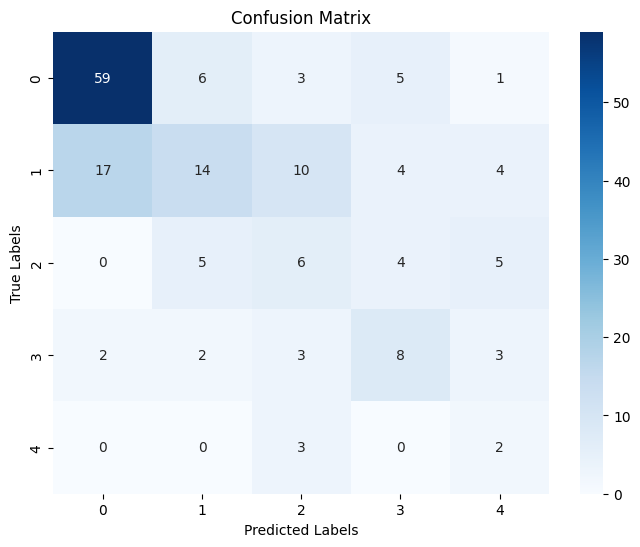

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize= (8,6))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

model = LogisticRegression()

params = {
    'C' : np.logspace(-4, 4, 20), # -4,0,4,8,12,16,20
    'solver' : ['liblinear'],
    'class_weight' : [None, 'balanced']
}

grid_search = GridSearchCV(model, param_grid=params, cv=5, scoring='f1_macro')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_
y_pred = grid_search.predict(X_test)

print(f'Best Parameters : {best_params}')
print(f'Best Score : {best_score}')

Best Parameters : {'C': np.float64(0.03359818286283781), 'class_weight': 'balanced', 'solver': 'liblinear'}
Best Score : 0.4925048959521643


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.81      0.77        74
           1       0.61      0.22      0.33        49
           2       0.26      0.25      0.26        20
           3       0.33      0.44      0.38        18
           4       0.13      0.60      0.21         5

    accuracy                           0.52       166
   macro avg       0.41      0.47      0.39       166
weighted avg       0.58      0.52      0.52       166



In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

model = LogisticRegression()

params = {
    'C' : np.logspace(-4, 4, 20), # -4,0,4,8,12,16,20
    'solver' : ['liblinear'],
    'class_weight' : [None, 'balanced']
}

grid_search = RandomizedSearchCV(model, params, cv=5, scoring='f1_macro')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_
y_pred = grid_search.predict(X_test)

print(f'Best Parameters : {best_params}')
print(f'Best Score : {best_score}')

Best Parameters : {'solver': 'liblinear', 'class_weight': 'balanced', 'C': np.float64(0.23357214690901212)}
Best Score : 0.4905998895390867


In [ ]:
import time, warnings, numpy as np, pandas as pd
from sklearn.metrics import classification_report, accuracy_score, f1_score, balanced_accuracy_score, matthews_corrcoef

# --- daftar model umum
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier, HistGradientBoostingClassifier)
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "LinearSVC": LinearSVC(dual="auto"),
    "SVC-RBF": SVC(kernel="rbf"),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=0),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=0),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=0),
}

# Tambahkan XGBoost/LightGBM jika terpasang (opsional)
try:
    from xgboost import XGBClassifier
    models["XGBClassifier"] = XGBClassifier(
        n_estimators=500, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, max_depth=6, random_state=0, n_jobs=-1, eval_metric="logloss"
    )
except Exception:
    pass

try:
    from lightgbm import LGBMClassifier
    models["LGBMClassifier"] = LGBMClassifier(
        n_estimators=600, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, random_state=42, n_jobs=-1
    )
except Exception:
    pass

warnings.filterwarnings("ignore")
results = []

for name, model in models.items():
    t0 = time.time()
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        print(f"\n=== {name} ===")
        print(classification_report(y_test, y_pred, digits=4))

        # ringkasan skor singkat untuk leaderboard
        results.append({
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro"),
            "bal_acc": balanced_accuracy_score(y_test, y_pred),
            "mcc": matthews_corrcoef(y_test, y_pred),
            "time_s": time.time() - t0
        })
    except Exception as e:
        print(f"\n=== {name} ERROR === {e}")

# leaderboard ringkas (urut F1-macro)
if results:
    df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
    print("\n=== Leaderboard (sorted by F1-macro) ===")
    print(df.to_string(index=False))


=== LogisticRegression ===
              precision    recall  f1-score   support

           0     0.7564    0.7973    0.7763        74
           1     0.5185    0.2857    0.3684        49
           2     0.2400    0.3000    0.2667        20
           3     0.3810    0.4444    0.4103        18
           4     0.1333    0.4000    0.2000         5

    accuracy                         0.5361       166
   macro avg     0.4058    0.4455    0.4043       166
weighted avg     0.5645    0.5361    0.5375       166


=== LinearSVC ===
              precision    recall  f1-score   support

           0     0.7093    0.8243    0.7625        74
           1     0.5882    0.2041    0.3030        49
           2     0.2381    0.2500    0.2439        20
           3     0.3478    0.4444    0.3902        18
           4     0.1053    0.4000    0.1667         5

    accuracy                         0.5181       166
   macro avg     0.3977    0.4246    0.3733       166
weighted avg     0.5594    0.5